In [4]:
import os
import pickle
import argparse
import numpy as np
import matplotlib.pyplot as plt

In [6]:

def plot_glue_results(experiment_path):
    config_path = os.path.join(experiment_path, "config.pkl")
    glue_path = os.path.join(experiment_path, "glue_metrics.pkl")
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file not found at {config_path}")
    if not os.path.exists(glue_path):
        raise FileNotFoundError(f"GLUE metrics file not found at {glue_path}")

    # Load configuration and metrics
    with open(config_path, 'rb') as f:
        config = pickle.load(f)
        
    with open(glue_path, 'rb') as f:
        full_results = pickle.load(f)

    figures_dir = os.path.join(experiment_path, "figures")
    os.makedirs(figures_dir, exist_ok=True)
    
    # Extract training tasks and infer metric names from the first available entry
    train_tasks = sorted(list(full_results.keys()))
    if not train_tasks:
        print("No GLUE data found to plot.")
        return

    first_eval_task = list(full_results[train_tasks[0]].keys())[0]
    metric_names = list(full_results[train_tasks[0]][first_eval_task].keys())
    
    # Setup subplots
    n_metrics = len(metric_names)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(12, 3 * n_metrics), sharex=True)
    if n_metrics == 1: 
        axes = [axes]
    
    # Initialize timeline storage
    timeline = {m: {} for m in metric_names}
    task_boundaries = []
    current_x = 0
    
    # Handle object attributes vs dictionary keys safely for the config
    log_frequency = getattr(config, 'log_frequency', 1)
    dataset_name = getattr(config, 'dataset_name', 'Dataset')

    for t_train in train_tasks:
        eval_tasks_in_train = list(full_results[t_train].keys())
        if not eval_tasks_in_train:
            continue
            
        # Determine number of steps in this training phase
        ref_eval_task = eval_tasks_in_train[0]
        steps = full_results[t_train][ref_eval_task][metric_names[0]].shape[0]
        
        segment_len = steps * log_frequency
        current_x += segment_len
        task_boundaries.append(current_x)
        
        # Aggregate data for each evaluated task
        for t_eval in eval_tasks_in_train:
            for m in metric_names:
                if t_eval not in timeline[m]:
                    timeline[m][t_eval] = {'mean': [], 'std': []}
                    
                data = full_results[t_train][t_eval][m]
                mean = np.nanmean(data, axis=1)
                std = np.nanstd(data, axis=1)
                
                timeline[m][t_eval]['mean'].append(mean)
                timeline[m][t_eval]['std'].append(std)

    x_axis = np.arange(0, current_x, log_frequency)
    all_eval_tasks = sorted(list(timeline[metric_names[0]].keys()))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(all_eval_tasks))))
    
    # Plotting loop
    for i, metric in enumerate(metric_names):
        ax = axes[i]
        
        for j, t_eval in enumerate(all_eval_tasks):
            means = timeline[metric][t_eval]['mean']
            stds = timeline[metric][t_eval]['std']
            
            if not means: continue
            
            # Concatenate timeline segments
            full_mean = np.concatenate(means)
            full_std = np.concatenate(stds)
            
            limit = min(len(x_axis), len(full_mean))
            
            ax.plot(x_axis[:limit], full_mean[:limit], label=t_eval, color=colors[j], linewidth=2)
            ax.fill_between(x_axis[:limit], 
                            full_mean[:limit] - full_std[:limit], 
                            full_mean[:limit] + full_std[:limit], 
                            color=colors[j], alpha=0.1)

        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
        
        # Draw vertical lines for task boundaries
        for boundary in task_boundaries[:-1]:
            ax.axvline(x=boundary, color='black', linestyle='--', alpha=0.5, linewidth=1.5)

        if i == 0:
            ax.set_title(f"GLUE Metrics Analysis - {dataset_name}")
            ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Evaluated Task")

    axes[-1].set_xlabel('Epochs')
    plt.tight_layout()
    plt.show()
    # save_path = os.path.join(figures_dir, f"glue_metrics_{dataset_name}.png")
    # plt.savefig(save_path)
    # print(f"GLUE plots saved to {save_path}")


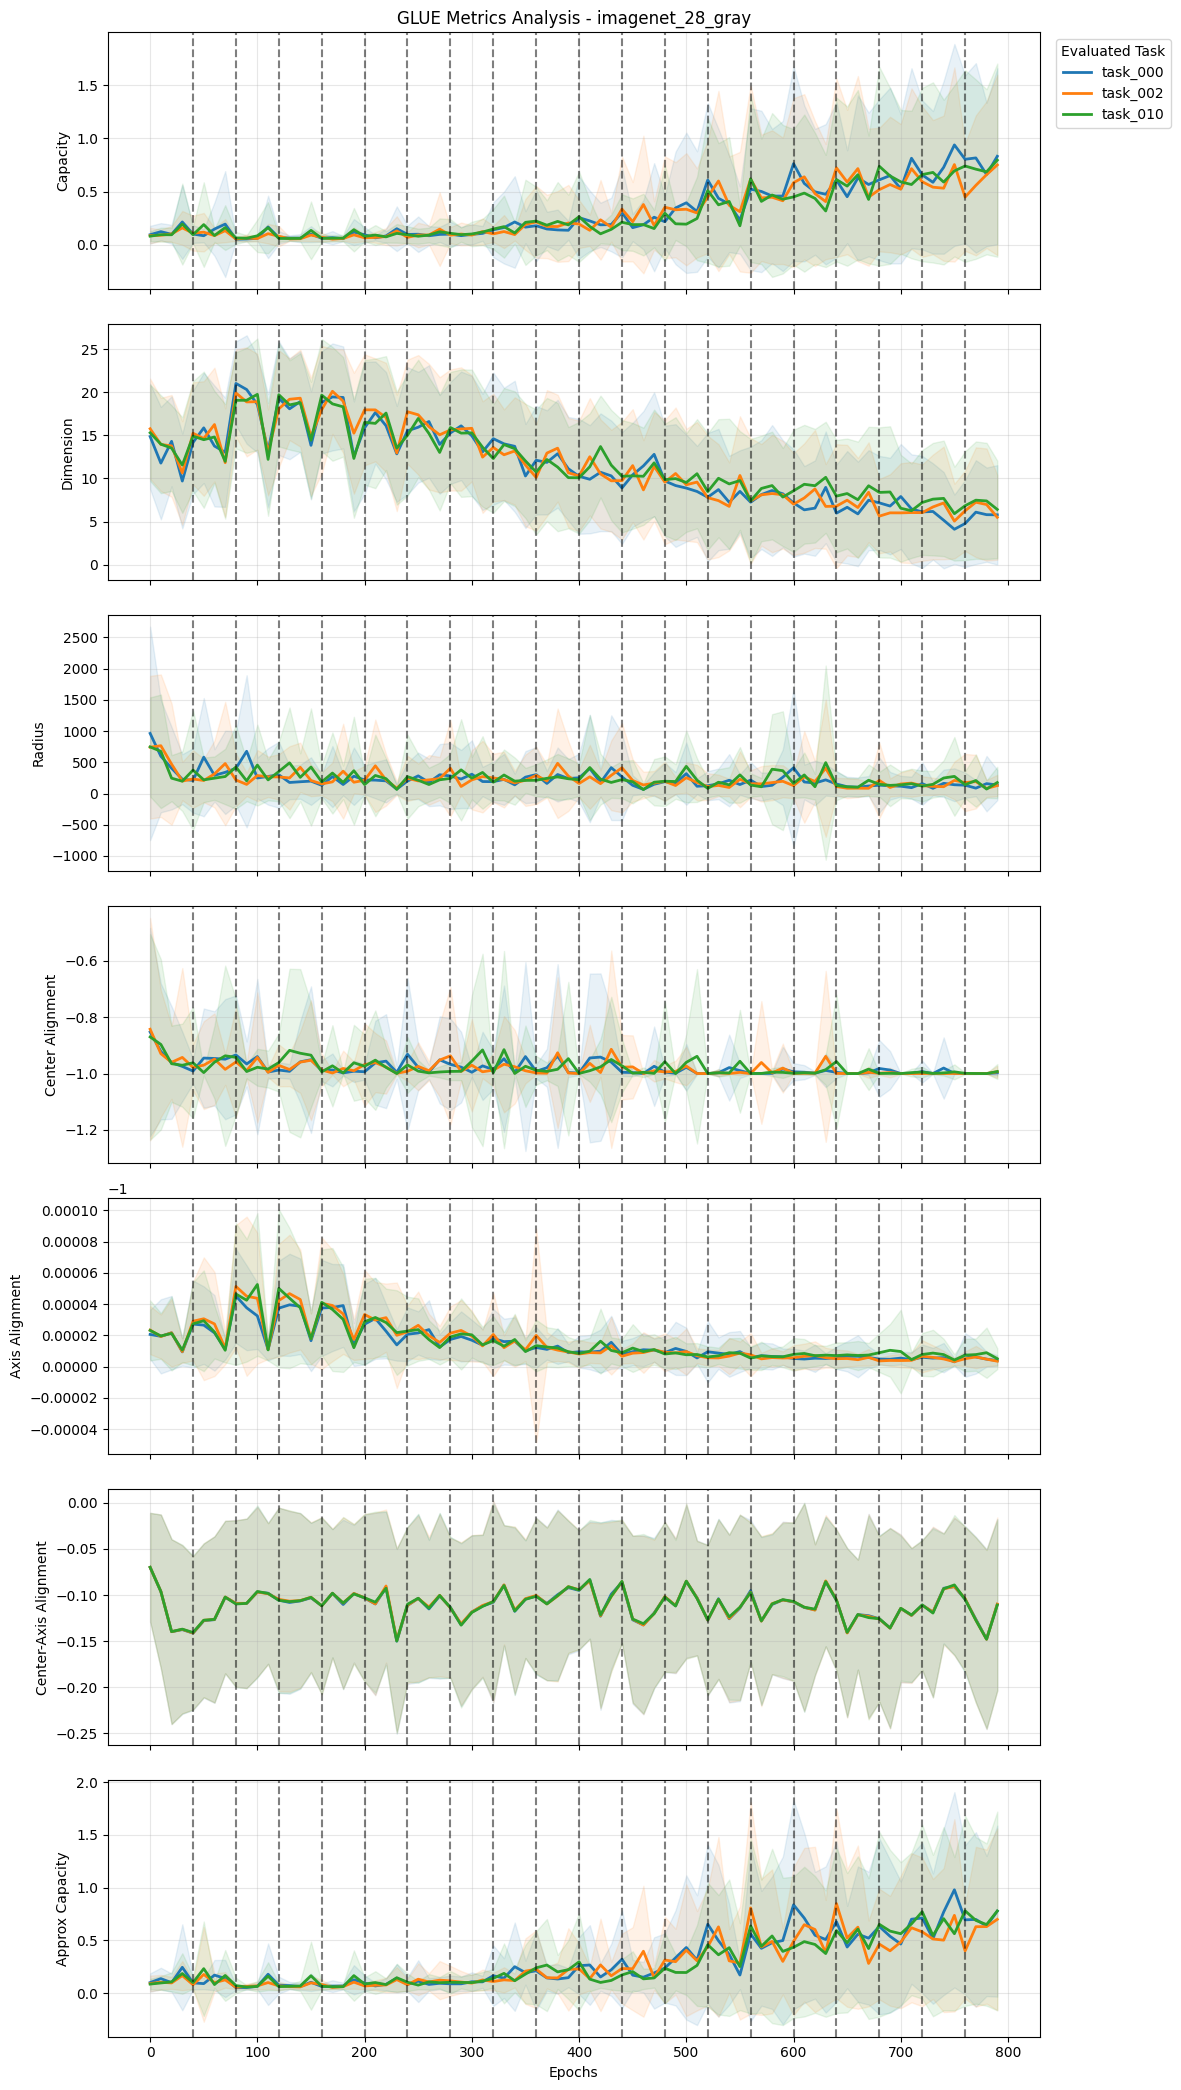

In [8]:
experiment_path = "/home/users/MTrappett/manifold/binary_classification/results/imagenet_28_gray/SL_20_tasks_lr1_0.01_lr2_0.0001"
plot_glue_results(experiment_path)